# Life Expectancy Prediction
### Data Loading, Preprocessing, Modelling & Evaluation

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap
import joblib

## 1. Load Data

In [3]:
df = pd.read_csv('Life Expectancy Data.csv')
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
df.tail()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.0,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.0,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.0,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.0,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8
2937,Zimbabwe,2000,Developing,46.0,665.0,24,1.68,0.0,79.0,1483,...,78.0,7.10,78.0,43.5,547.358878,12222251.0,11.0,11.2,0.434,9.8


In [5]:
df.shape

(2938, 22)

In [6]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [8]:
df['Status'].value_counts()

Status
Developing    2426
Developed      512
Name: count, dtype: int64

In [9]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [10]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

## 2. Preprocessing

In [11]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Drop Country (high-cardinality categorical, not useful as a numeric feature)
df.drop('Country', axis=1, inplace=True)

# Encode 'Status' column (Developed/Developing → 0/1)
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])
print('Status classes:', le.classes_)

# Impute missing values with column mean
num_cols = df.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='mean')
df[num_cols] = imputer.fit_transform(df[num_cols])
print('Missing values after imputation:', df.isnull().sum().sum())

df.head()

Status classes: ['Developed' 'Developing']
Missing values after imputation: 0


,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015.0,1.0,65.0,263.0,62.0,0.01,71.279624,65.0,1154.0,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014.0,1.0,59.9,271.0,64.0,0.01,73.523582,62.0,492.0,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013.0,1.0,59.9,268.0,66.0,0.01,73.219243,64.0,430.0,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012.0,1.0,59.5,272.0,69.0,0.01,78.184215,67.0,2787.0,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011.0,1.0,59.2,275.0,71.0,0.01,7.097109,68.0,3013.0,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## 3. Exploratory Data Analysis

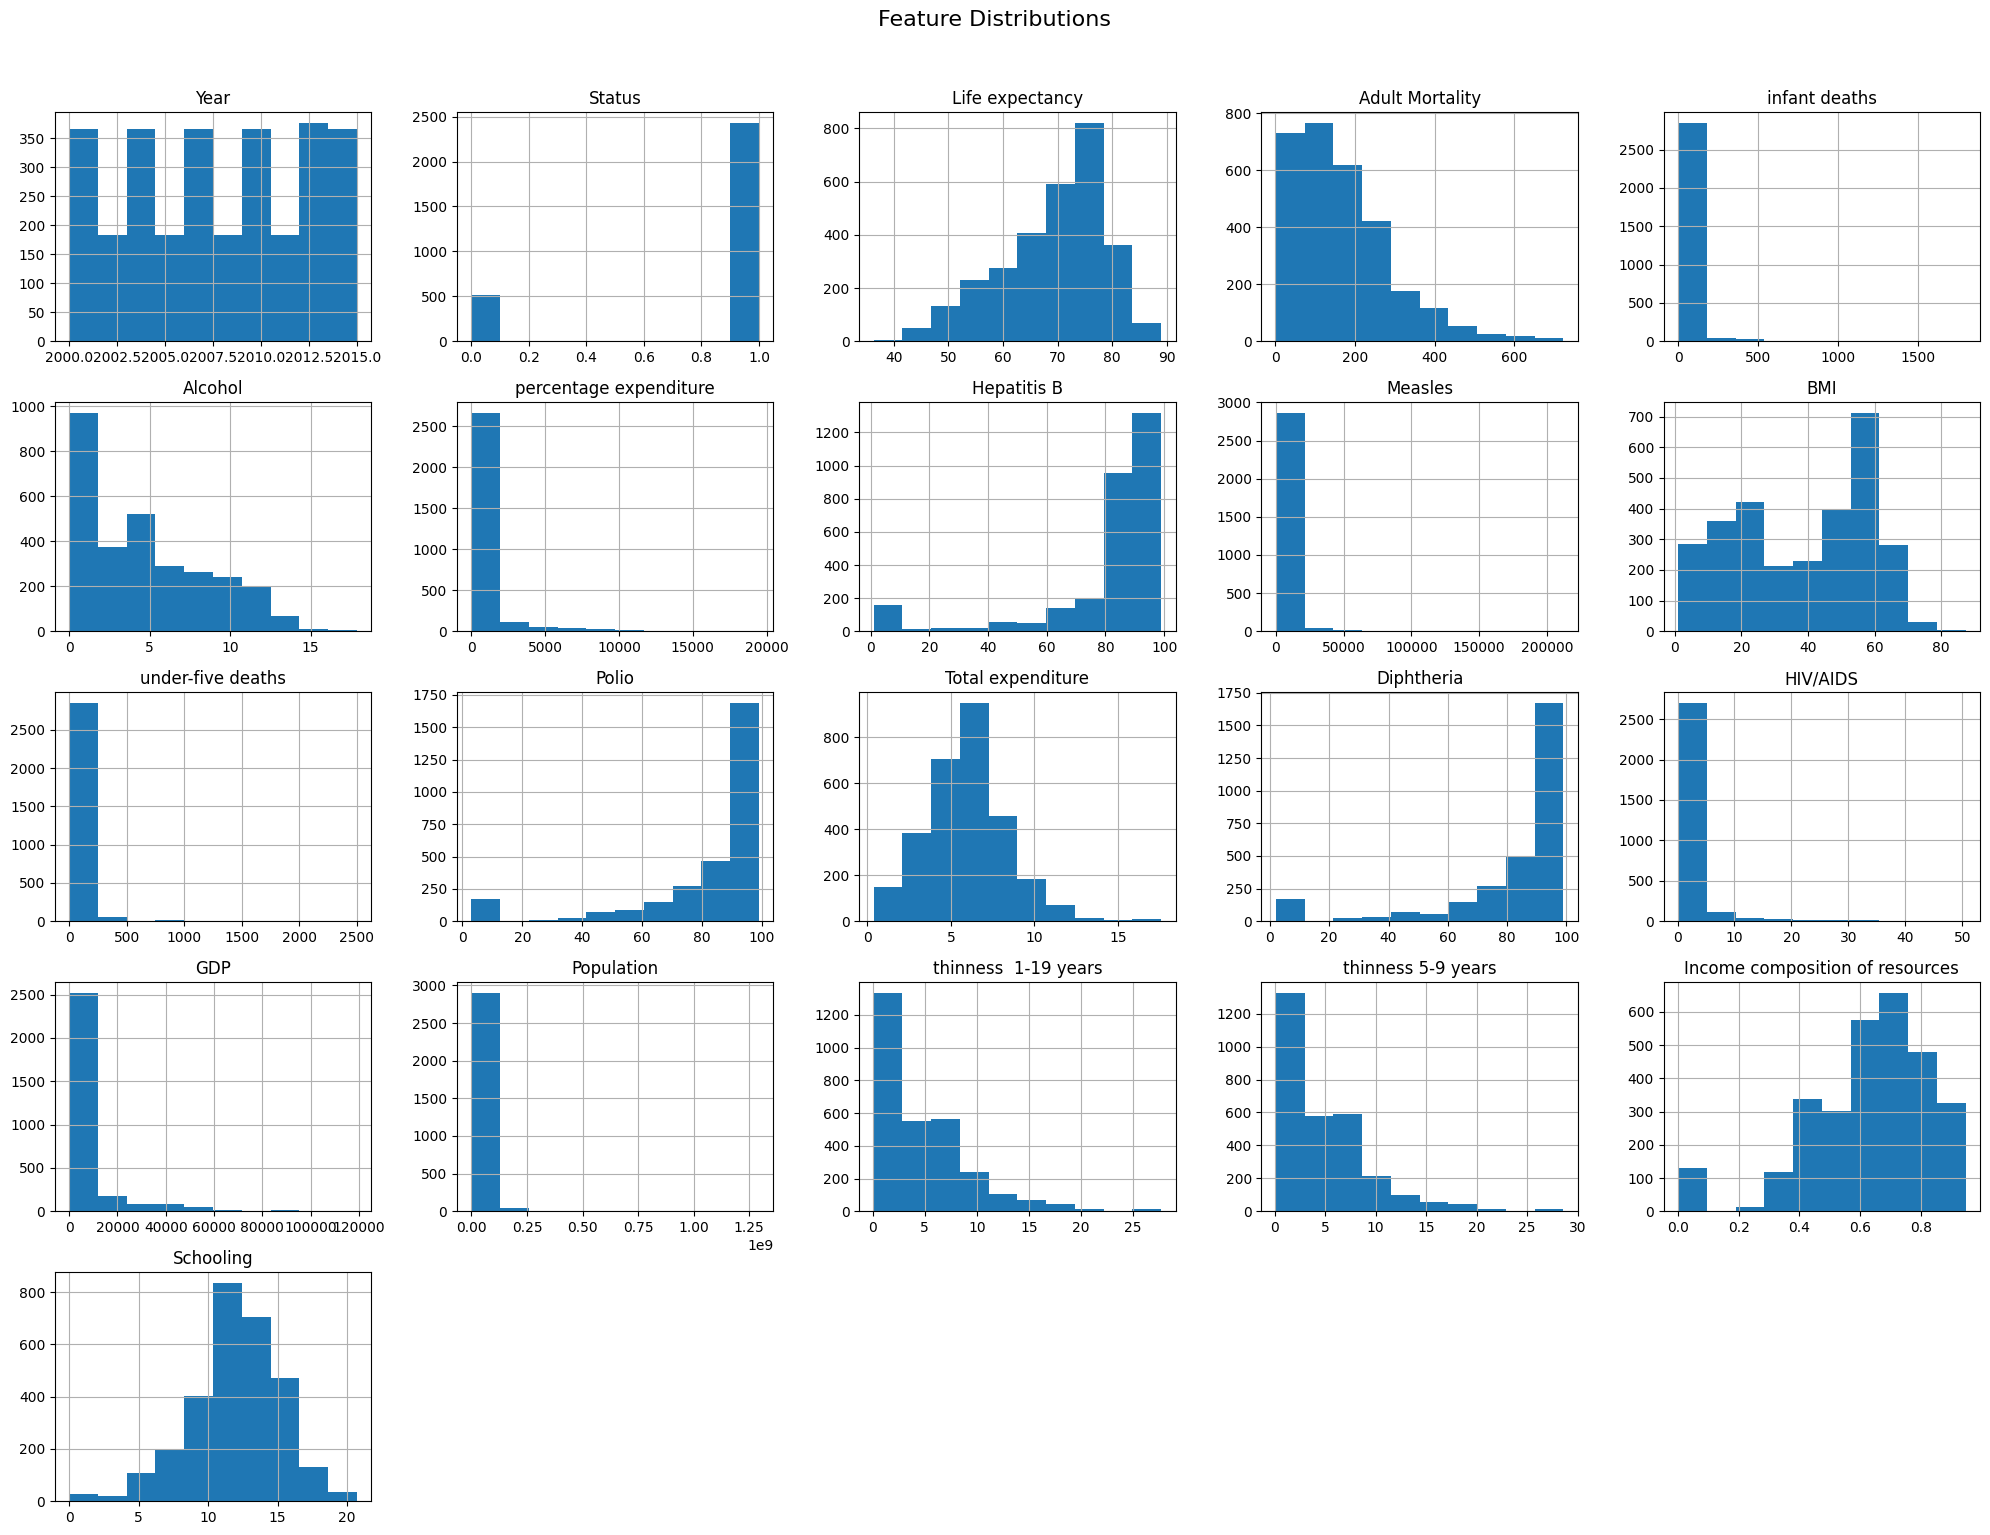

In [12]:
df.hist(figsize=(20, 15))
plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

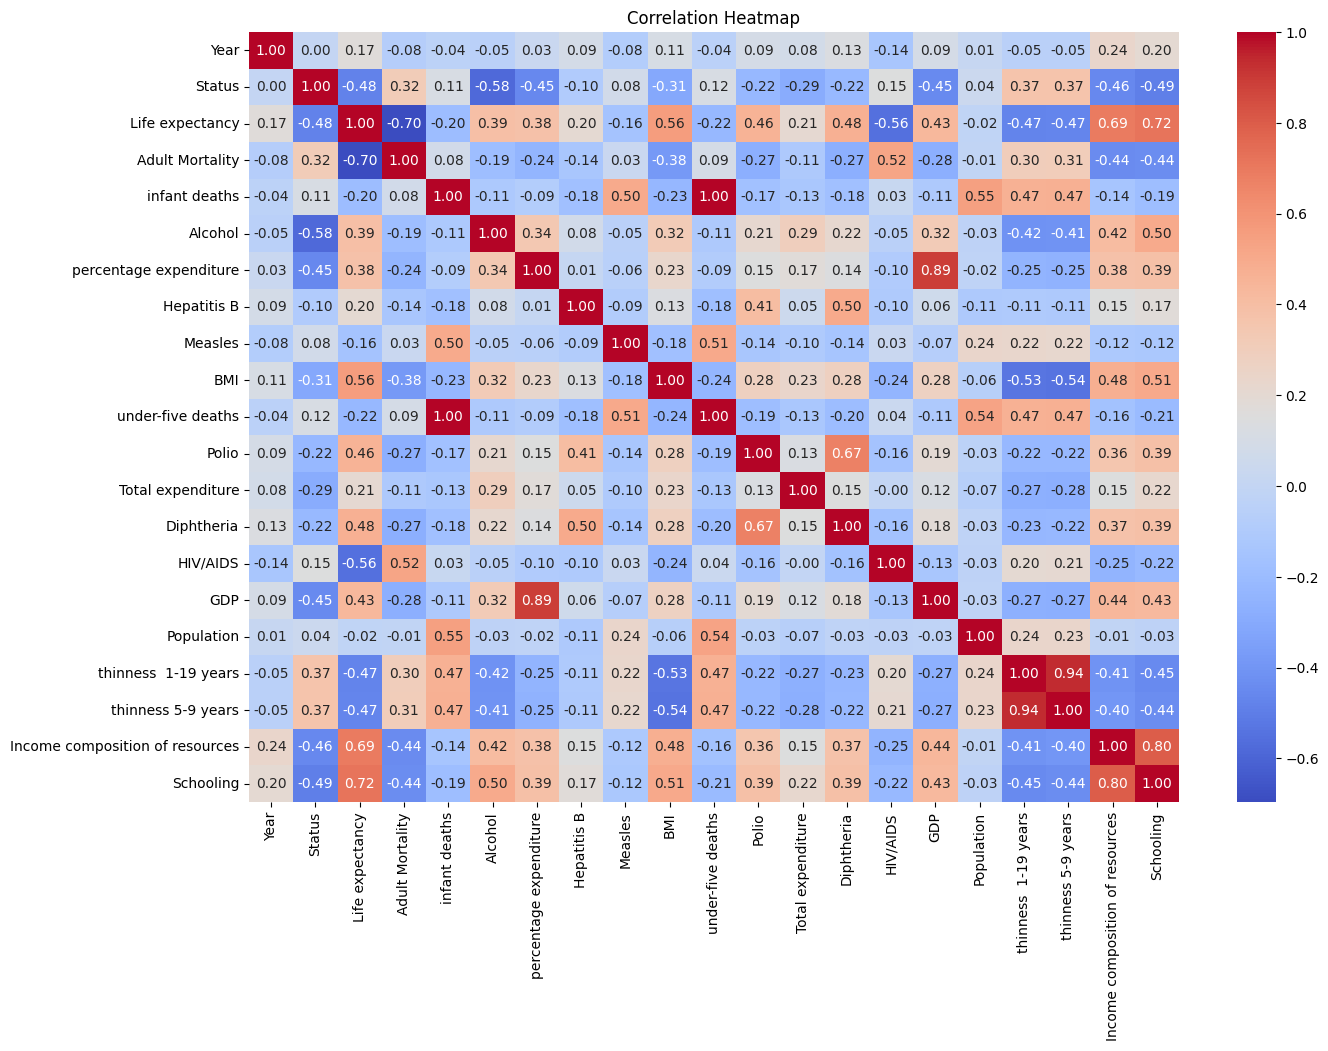

In [13]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

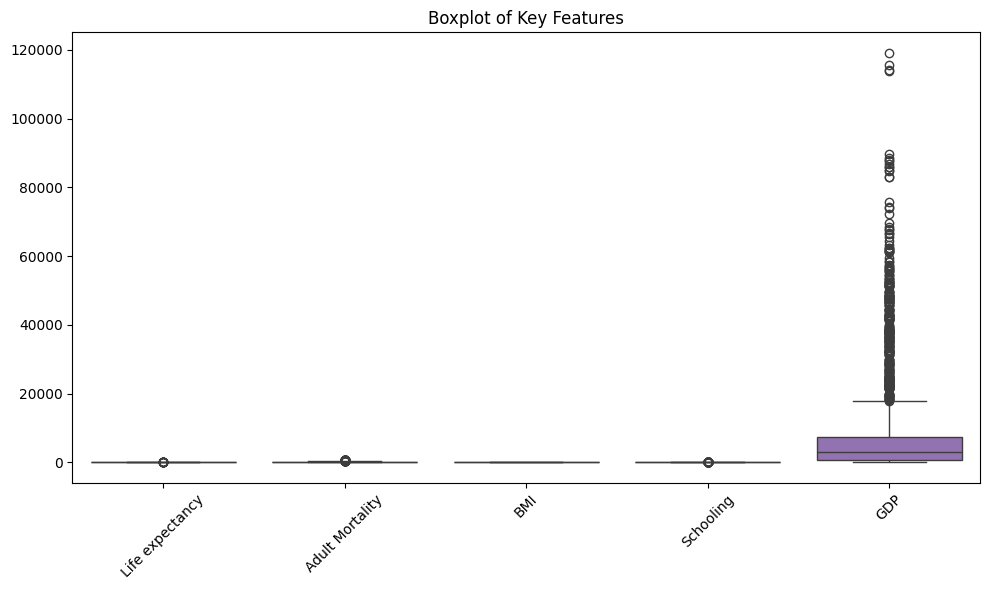

In [14]:
plt.figure(figsize=(10, 6))
key_cols = ['Life expectancy', 'Adult Mortality', 'BMI', 'Schooling', 'GDP']
sns.boxplot(data=df[key_cols])
plt.xticks(rotation=45)
plt.title('Boxplot of Key Features')
plt.tight_layout()
plt.show()

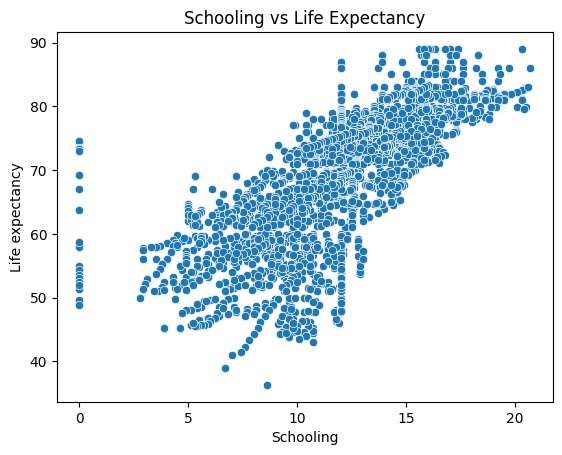

In [15]:
sns.scatterplot(x='Schooling', y='Life expectancy', data=df)
plt.title('Schooling vs Life Expectancy')
plt.show()

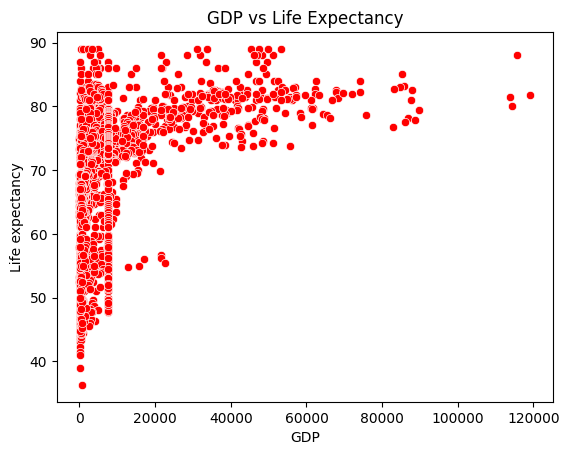

In [16]:
sns.scatterplot(x='GDP', y='Life expectancy', data=df ,color="red")
plt.title('GDP vs Life Expectancy')
plt.show()

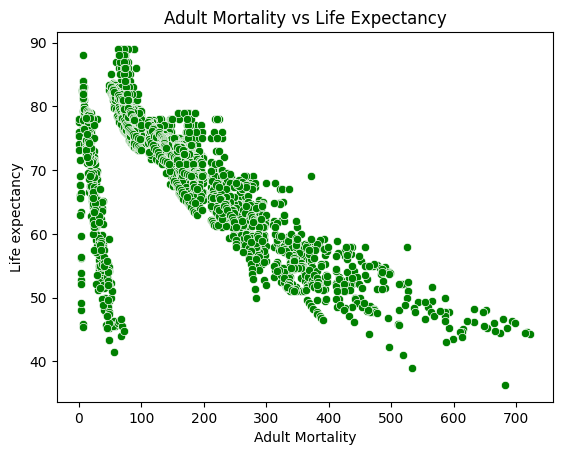

In [17]:
sns.scatterplot(x='Adult Mortality', y='Life expectancy', data=df, color="green")
plt.title('Adult Mortality vs Life Expectancy')
plt.show()

## 4. Model Training

In [18]:
# Define selected features and target

selected_features = [
    'Adult Mortality',
    'BMI',
    'Schooling',
    'HIV/AIDS',
    'GDP'
]

y = df['Life expectancy']
X = df[selected_features]

print("Selected Features:", selected_features)
print("Feature shape:", X.shape)
    
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train size:', X_train_scaled.shape, '| Test size:', X_test_scaled.shape)

Selected Features: ['Adult Mortality', 'BMI', 'Schooling', 'HIV/AIDS', 'GDP']
Feature shape: (2938, 5)
Train size: (2350, 5) | Test size: (588, 5)


In [19]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print('LINEAR REGRESSION')
print('MAE  :', round(mean_absolute_error(y_test, y_pred_lr), 4))
print('RMSE :', round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 4))
print('R2   :', round(r2_score(y_test, y_pred_lr), 4))

LINEAR REGRESSION
MAE  : 3.1565
RMSE : 4.3855
R2   : 0.778


In [20]:
dt = DecisionTreeRegressor(random_state=42, min_samples_split=10, max_depth=10)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print('DECISION TREE')
print('MAE  :', round(mean_absolute_error(y_test, y_pred_dt), 4))
print('RMSE :', round(np.sqrt(mean_squared_error(y_test, y_pred_dt)), 4))
print('R2   :', round(r2_score(y_test, y_pred_dt), 4))

DECISION TREE
MAE  : 1.6675
RMSE : 2.3902
R2   : 0.9341


In [21]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print('RANDOM FOREST')
print('MAE  :', round(mean_absolute_error(y_test, y_pred_rf), 4))
print('RMSE :', round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 4))
print('R2   :', round(r2_score(y_test, y_pred_rf), 4))

RANDOM FOREST
MAE  : 1.2644
RMSE : 1.8529
R2   : 0.9604


In [22]:
# ── XGBoost Regression ──────────────────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

print('XGBOOST REGRESSOR')
print('MAE  :', round(mean_absolute_error(y_test, y_pred_xgb), 4))
print('RMSE :', round(np.sqrt(mean_squared_error(y_test, y_pred_xgb)), 4))
print('R2   :', round(r2_score(y_test, y_pred_xgb), 4))

XGBOOST REGRESSOR
MAE  : 1.363
RMSE : 1.9139
R2   : 0.9577


## 5. Cross-Validation (Random Forest)

In [23]:
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

cv_scores = cross_val_score(pipe_rf, X, y, cv=5, scoring='r2')
print('CV R2 scores:', cv_scores.round(4))
print('Average R2  :', round(cv_scores.mean(), 4))

CV R2 scores: [0.9442 0.8888 0.9195 0.9078 0.9139]
Average R2  : 0.9148


In [24]:
# ── 5-Fold Cross-Validation for XGBoost ─────────────────────────────────────
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])

cv_scores_xgb = cross_val_score(pipe_xgb, X, y, cv=5, scoring='r2')
print('XGBoost CV R2 scores:', cv_scores_xgb.round(4))
print('XGBoost Average R2  :', round(cv_scores_xgb.mean(), 4))

XGBoost CV R2 scores: [0.9444 0.8853 0.9196 0.9113 0.8998]
XGBoost Average R2  : 0.9121


## 6. Feature Importance

In [25]:
importance = rf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance.to_string(index=False))

        Feature  Importance
       HIV/AIDS    0.598415
Adult Mortality    0.248291
      Schooling    0.096873
            BMI    0.043595
            GDP    0.012826


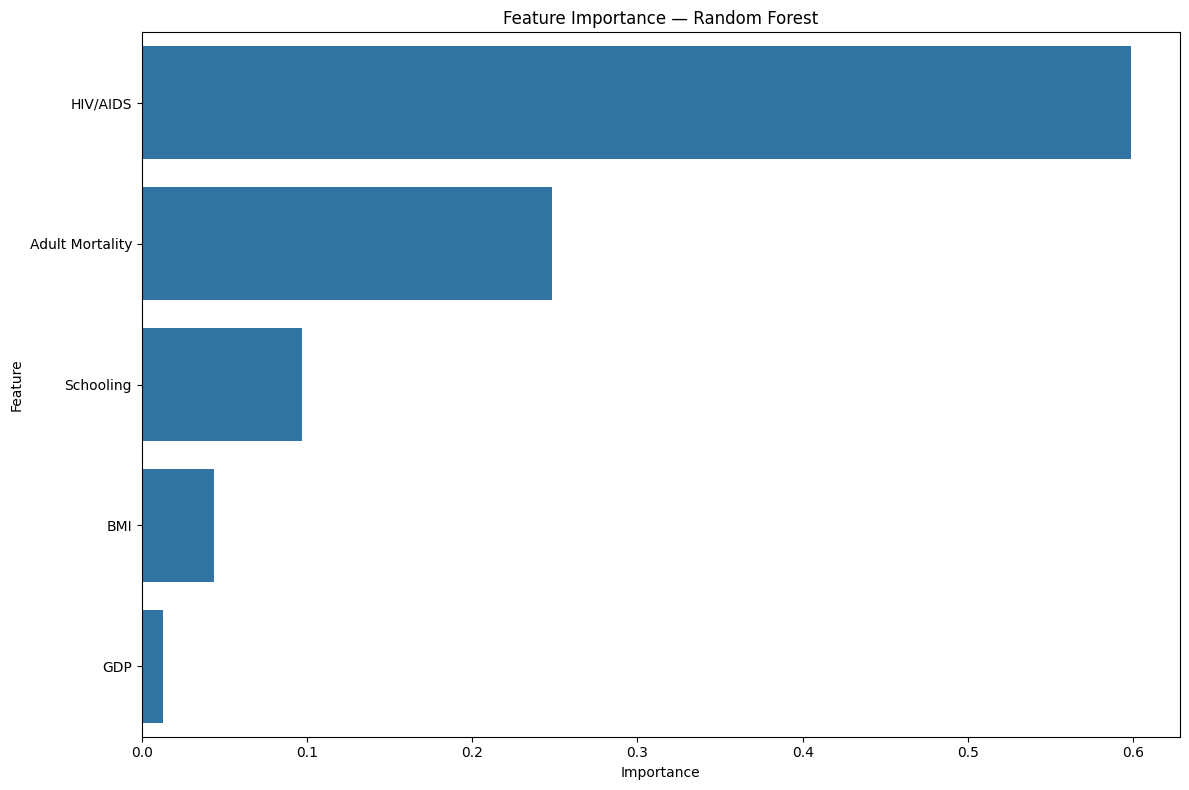

In [26]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

## 6b. Explainable AI (XAI) — SHAP Analysis

SHAP Summary Plot (Beeswarm)


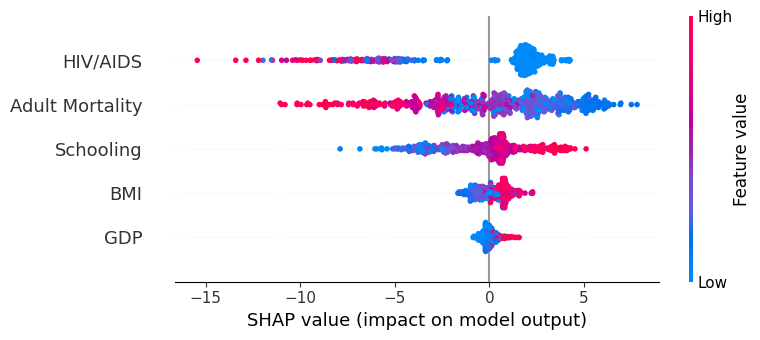

SHAP Feature Importance Bar Plot


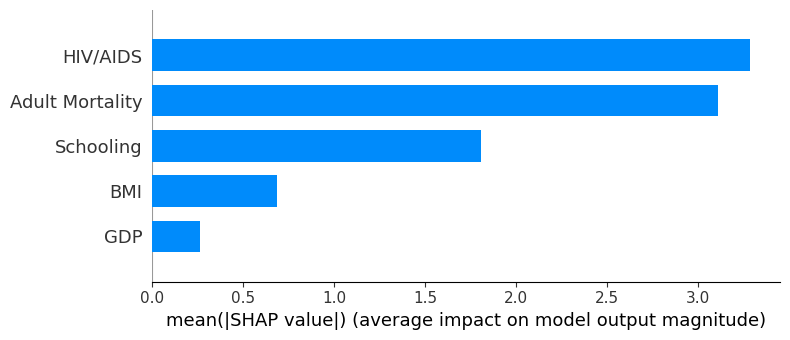

In [27]:
# ── SHAP Analysis using the trained XGBoost model ───────────────────────────
# Convert scaled array to DataFrame to preserve feature names for SHAP
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# TreeExplainer is fast and exact for tree-based models like XGBoost
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_scaled_df)

# SHAP Summary Plot — shows impact and direction of each feature
print('SHAP Summary Plot (Beeswarm)')
shap.summary_plot(shap_values, X_test_scaled_df, show=True)

# SHAP Feature Importance Bar Plot — mean absolute SHAP value per feature
print('SHAP Feature Importance Bar Plot')
shap.summary_plot(shap_values, X_test_scaled_df, plot_type='bar', show=True)

## 7. Model Comparison

In [28]:
r2_lr  = r2_score(y_test, y_pred_lr)
r2_dt  = r2_score(y_test, y_pred_dt)
r2_rf  = r2_score(y_test, y_pred_rf)
r2_xgb = r2_score(y_test, y_pred_xgb)

results = pd.DataFrame({
    'Model':    ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'R2 Score': [r2_lr, r2_dt, r2_rf, r2_xgb]
})
print(results.to_string(index=False))

            Model  R2 Score
Linear Regression  0.778000
    Decision Tree  0.934056
    Random Forest  0.960370
          XGBoost  0.957719


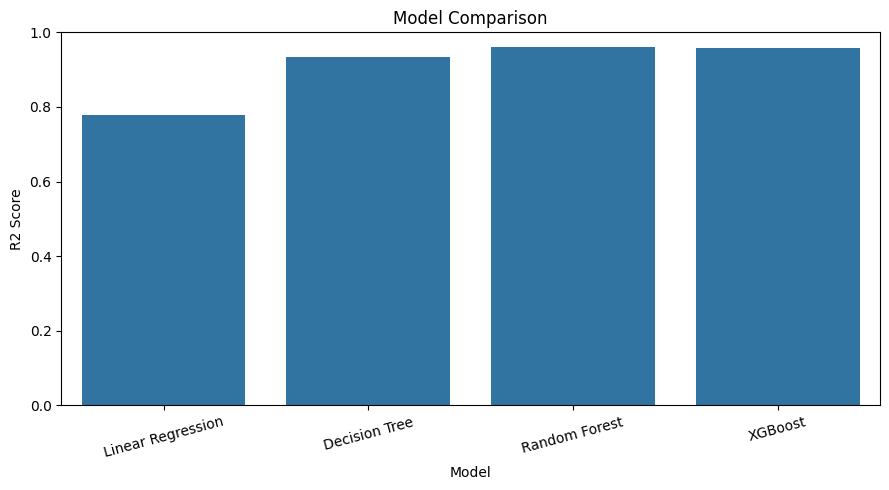

Best model: Random Forest


In [29]:
plt.figure(figsize=(9, 5))
sns.barplot(x='Model', y='R2 Score', data=results)
plt.ylabel('R2 Score')
plt.title('Model Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best = results.loc[results['R2 Score'].idxmax(), 'Model']
print(f'Best model: {best}')

## 8. Save Best Model

In [30]:
joblib.dump(xgb, "life_expectancy_model.pkl")
joblib.dump(scaler, "life_expectancy_scaler.pkl")

['life_expectancy_scaler.pkl']